# EXP6b — ALD Variance-head results (streamflow first, calibration last)

Deliberate order: **understand the uncertainty hydrologically before any ML metric.**
1. Event hydrographs at the 2021 extremes. 
2. Where the uncertainty lives (map).
3. Uncertainty by glaciation class (bridge to EXP4a). 
4. Predicted vs realized error byflow. 
5. **Only then**: formal calibration (PIT + regime coverage). PIT answers what the magnitude plots can't — do the intervals actually *cover*, given the shape.

In [1]:
# Cell 1: imports + config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import norm

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

from src.config import OUTPUT_DATA_DIR, PROCESSED_DATA_DIR
RESULTS = OUTPUT_DATA_DIR / "results_MVE"; VAR = RESULTS / "variance_ald"
EVENTS = {"heat_dome_2021": ("2021-06-01","2021-07-31"),
          "ar_flood_2021":  ("2021-10-20","2021-12-10")}

In [2]:
# Cell 2: load grids + station attributes, aligned on the (date, station) grid
idx = pd.read_csv(RESULTS/"index_dates.csv", parse_dates=["date"])
dates = pd.DatetimeIndex(idx["date"]); split = idx["split"].to_numpy()
y = np.load(RESULTS/"y_obs_mm.npy"); valid = np.load(RESULTS/"valid_mask_ald.npy")
pred = np.load(VAR/"predictive.npz")
mu, sigma_e2, sigma_a2, var_total = pred["mu_hat"], pred["sigma_e2"], pred["sigma_a2"], pred["var_total"]
stations = pd.read_csv(RESULTS/"q_std.csv")["station_id"].astype(str).to_numpy()
S = len(stations); ald = (split=="test")[:,None] & valid
sig_tot, sig_e, sig_a = np.sqrt(var_total), np.sqrt(sigma_e2), np.sqrt(sigma_a2)

# --- ALD predictive: params + CDF/quantile helpers + mean-freeze 95% band (physical) ---
aldp = np.load(VAR/"ald_params.npz")
b_ald, tau_ald, q_std = aldp["scale_z"], aldp["tau"], aldp["q_std"]
m_z = -b_ald * (1.0 - 2.0*tau_ald) / (tau_ald*(1.0 - tau_ald))     # location so E[z]=0 (=> E[y]=mu_hat)

def ald_cdf(zz, m, b, tau):
    """CDF of ALD(location m, scale b, asymmetry tau) on the standardized residual z."""
    return np.where(zz < m, tau*np.exp((1-tau)/b*(zz-m)),
                    1 - (1-tau)*np.exp(-tau/b*(zz-m)))

def ald_quantile(pp, m, b, tau):
    """Inverse CDF (quantile) of ALD(m,b,tau); pp is a scalar in (0,1)."""
    return np.where(pp <= tau, m + b/(1-tau)*np.log(pp/tau),
                    m - b/tau*np.log((1-pp)/(1-tau)))

# physical 95% ALD ALEATORIC interval — ASYMMETRIC (not mu +/- 1.96*sigma)
ald_lo = mu + q_std[None,:]*ald_quantile(0.025, m_z, b_ald, tau_ald)
ald_hi = mu + q_std[None,:]*ald_quantile(0.975, m_z, b_ald, tau_ald)

stat = pd.read_csv(PROCESSED_DATA_DIR/"static_attributes.csv")
stat["station_id"] = stat["station_id"].astype(str)
stat = stat.set_index("station_id").reindex(stations)
gp, lon, lat = stat["glacier_pct"].to_numpy(), stat["longitude"].to_numpy(), stat["latitude"].to_numpy()
GLAC = np.select([gp==0,(gp>0)&(gp<1),(gp>=1)&(gp<=5),gp>5],
                 ["non","low (<1%)","med (1-5%)","high (>5%)"], default="na")
GORDER = ["non","low (<1%)","med (1-5%)","high (>5%)"]

def per_station_median(a):
    out = np.full(S, np.nan)
    for j in range(S):
        m = ald[:,j]
        if m.any(): out[j] = np.median(a[m,j])
    return out
print("grid", y.shape, "| ald+valid cells", int(ald.sum()))

grid (15706, 269) | ald+valid cells 877729


## 1. Event hydrographs — the 2021 extremes
obs vs ensemble mean μ̂ with the **skew-aware 95% ALD interval** (aleatoric, *asymmetric* — no longer μ̂ ± 1.96σ) plus the thin symmetric ±1.96 σ_e ensemble band. Read the mean shrinkage, the sliver-thin ensemble band, and whether the asymmetric interval reaches the peak.

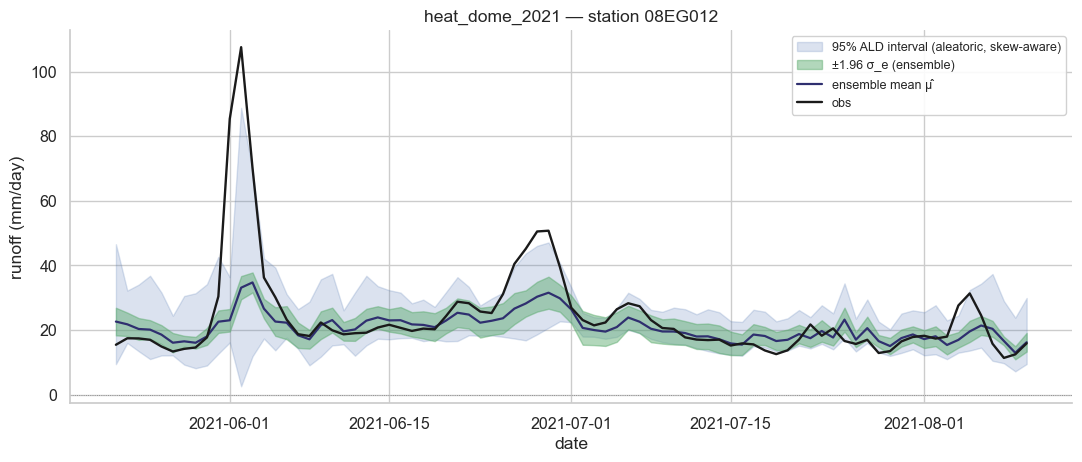

heat_dome_2021 st 08EG012: peak obs 107.6 | mu 33.1 (mu/obs 0.31) | ALD 95% [2.6, 88.8] covered=False


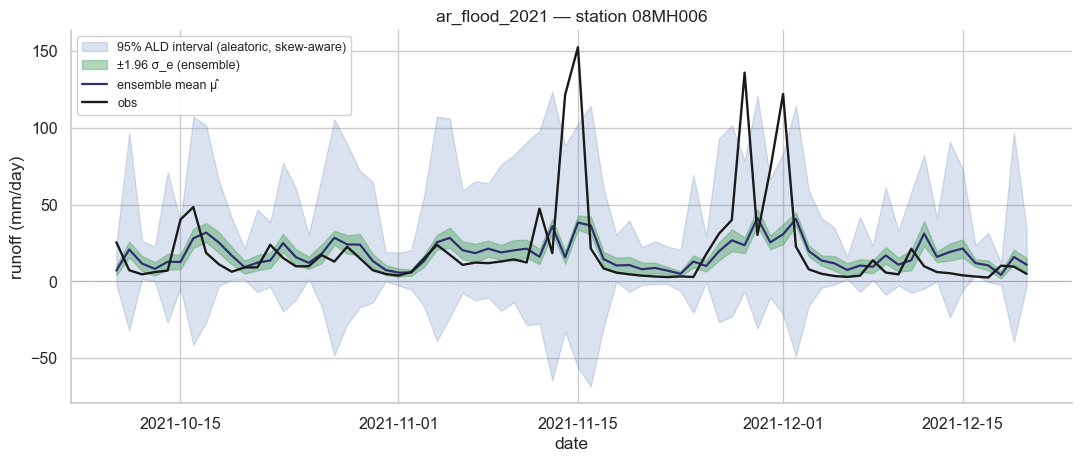

ar_flood_2021 st 08MH006: peak obs 152.5 | mu 38.3 (mu/obs 0.25) | ALD 95% [-56.2, 102.6] covered=False


In [3]:
# Cell 3: Q-extreme hydrographs (skew-aware ALD interval, not mu +/- 1.96 sigma)
Z = 1.96
pal = dict(total="#4c72b0", epi="#55a868", mu="#2f2f6f")
def plot_event(name, a, b, station=None, pad_days=10):
    w = (dates >= pd.Timestamp(a)-pd.Timedelta(days=pad_days)) & (dates <= pd.Timestamp(b)+pd.Timedelta(days=pad_days))
    wi = np.where(w)[0]
    if station is None:
        core = (dates>=a)&(dates<=b)
        j = int(np.nanargmax(np.nanmax(np.where(core[:,None]&valid, y, np.nan), axis=0)))
    else:
        j = int(np.where(stations==station)[0][0])
    d=dates[wi]; o=y[wi,j]; m=mu[wi,j]; sE=sig_e[wi,j]; lo=ald_lo[wi,j]; hi=ald_hi[wi,j]
    fig,ax=plt.subplots(figsize=(11,4.8))
    ax.fill_between(d, lo, hi, color=pal["total"], alpha=.20, label="95% ALD interval (aleatoric, skew-aware)")
    ax.fill_between(d, m-Z*sE, m+Z*sE, color=pal["epi"], alpha=.45, label="±1.96 σ_e (ensemble)")
    ax.plot(d,m,color=pal["mu"],lw=1.6,label="ensemble mean μ̂")
    ax.plot(d,o,color="k",lw=1.7,label="obs")
    ax.axhline(0,color="grey",lw=.6,ls=":")
    ax.set(title=f"{name} — station {stations[j]}",xlabel="date",ylabel="runoff (mm/day)")
    ax.legend(fontsize=9, framealpha=.9); sns.despine(ax=ax); plt.tight_layout(); plt.show()
    dc=(d>=pd.Timestamp(a))&(d<=pd.Timestamp(b)); pk=int(np.nanargmax(np.where(dc,o,np.nan)))
    print(f"{name} st {stations[j]}: peak obs {o[pk]:.1f} | mu {m[pk]:.1f} (mu/obs {m[pk]/o[pk]:.2f}) "
          f"| ALD 95% [{lo[pk]:.1f}, {hi[pk]:.1f}] covered={o[pk] <= hi[pk]}")
for _n,(_a,_b) in EVENTS.items(): plot_event(_n,_a,_b)

## 2. Where does the uncertainty live?
Per-station median predictive σ (mm/day) and epistemic share, on a BC/Alberta basemap.

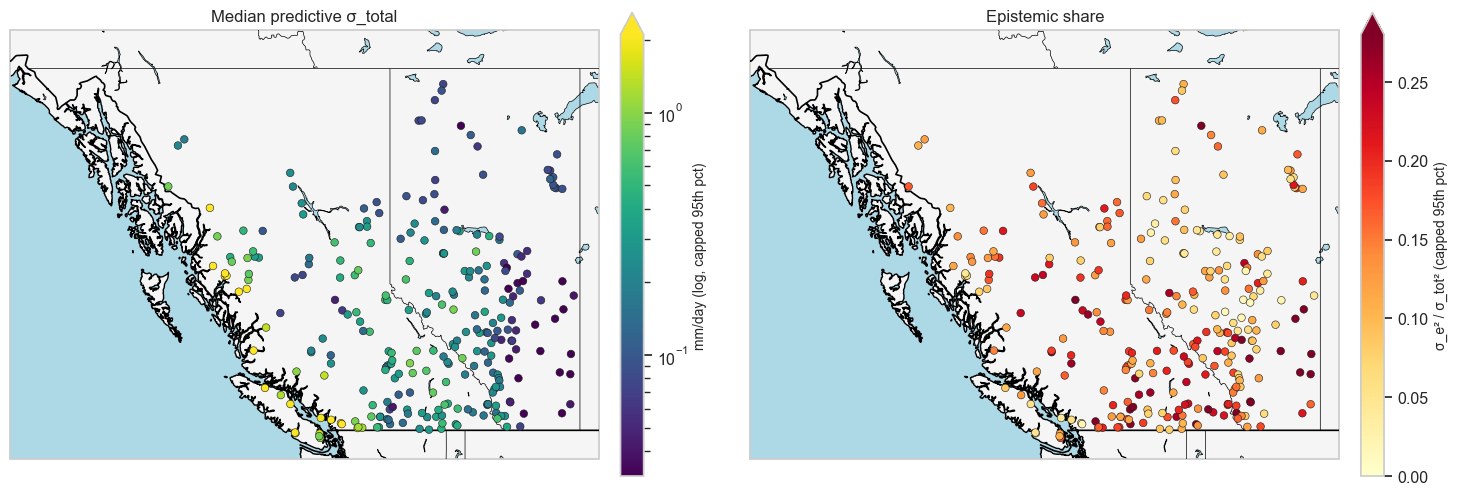

In [4]:
# Cell 4: spatial maps (EXP4a basemap style: Mercator, 10m features, robust caps)
med_stot = per_station_median(sig_tot); epi_share = per_station_median(sigma_e2/var_total)
RES = "10m"
def draw_base(ax):
    ax.set_extent([-140, -109, 48, 61], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND.with_scale(RES), facecolor="whitesmoke", zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale(RES), facecolor="lightblue", zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale(RES), edgecolor="black", zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale(RES), facecolor="lightblue", edgecolor="black", linewidth=0.5, zorder=2)
    provs = cfeature.NaturalEarthFeature("cultural", "admin_1_states_provinces_lines", scale=RES, facecolor="none")
    ax.add_feature(provs, edgecolor="black", linewidth=0.5, zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale(RES), edgecolor="black", linewidth=1.2, zorder=3)

fig, axes = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={"projection": ccrs.Mercator()})
# robust caps (95th pct) so a few flashy basins do not wash out the scale (matches EXP4a)
vmax_s = float(np.nanpercentile(med_stot, 95)); vmin_s = float(np.nanpercentile(med_stot[med_stot > 0], 5))
share_max = float(np.nanpercentile(epi_share, 95))
panels = [("Median predictive σ_total", "mm/day (log, capped 95th pct)", med_stot, "viridis",
           mcolors.LogNorm(vmin=vmin_s, vmax=vmax_s)),
          ("Epistemic share", "σ_e² / σ_tot² (capped 95th pct)", epi_share, "YlOrRd",
           mcolors.Normalize(0, share_max))]
for ax, (title, clab, vals, cmap, cnorm) in zip(axes, panels):
    draw_base(ax)
    sc = ax.scatter(lon, lat, c=vals, cmap=cmap, norm=cnorm, s=30, marker="o",
                    edgecolors="k", linewidths=0.4, zorder=5, transform=ccrs.PlateCarree())
    cb = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.7, pad=0.03, extend="max")
    cb.set_label(clab, fontsize=10)
    ax.set_title(title, fontsize=12)
plt.tight_layout(); plt.show()

## 3. Uncertainty by glaciation class (EXP4a bridge)
Physical thresholds (non / <1% / 1–5% / >5%). Do glacier-fed basins carry distinct uncertainty structure?

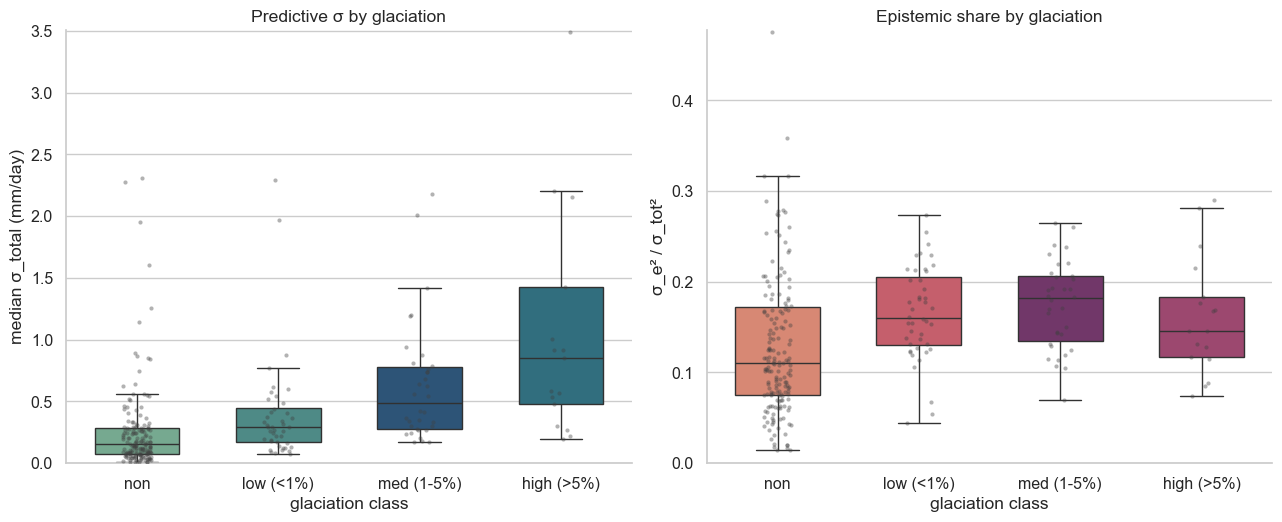

non         n=174  median σ_total 0.152
low (<1%)   n= 44  median σ_total 0.292
med (1-5%)  n= 34  median σ_total 0.484
high (>5%)  n= 17  median σ_total 0.851


In [5]:
# Cell 5: sigma by glaciation class (seaborn; y capped at 97.5th pct so flashy basins do not squash the boxes)
dfg = pd.DataFrame({"glac": GLAC, "median σ_total": med_stot, "epistemic share": epi_share})
dfg = dfg[dfg["glac"] != "na"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, (col, pal_) in zip(axes, [("median σ_total", "crest"), ("epistemic share", "flare")]):
    cap = float(np.nanpercentile(dfg[col], 97.5))
    sns.boxplot(data=dfg, x="glac", y=col, order=GORDER, hue="glac", palette=pal_,
                legend=False, showfliers=False, width=.6, ax=ax)
    sns.stripplot(data=dfg, x="glac", y=col, order=GORDER, color="0.25", size=3, alpha=.4, ax=ax)
    ax.set_ylim(0, cap); ax.set_xlabel("glaciation class")
axes[0].set(title="Predictive σ by glaciation", ylabel="median σ_total (mm/day)")
axes[1].set(title="Epistemic share by glaciation", ylabel="σ_e² / σ_tot²")
sns.despine(fig); plt.tight_layout(); plt.show()
for c in GORDER:
    print(f"{c:11s} n={int((GLAC==c).sum()):3d}  median σ_total {np.nanmedian(med_stot[GLAC==c]):.3f}")

## 4. Does the variance make physical sense? — predicted vs realized error by flow
Both RMS-consistent: predicted = √E[σ_total²], realized = √E[(y−μ̂)²], per within-basin flow decile. 

Predicted is *generous* through the body and about-right in *magnitude* at the top decile — so the variance scale is reasonable. 

That is exactly why magnitude alone can't tell us if we're calibrated: the peaks can still escape on **shape**. → coverage check next.

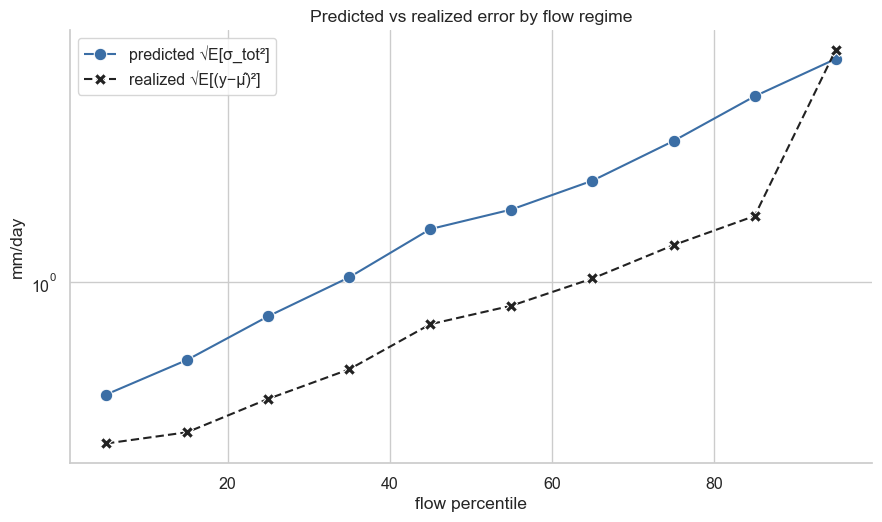

0-10%: predicted 0.437  realized 0.305  ratio 1.43
10-20%: predicted 0.565  realized 0.331  ratio 1.70
20-30%: predicted 0.779  realized 0.424  ratio 1.84
30-40%: predicted 1.038  realized 0.527  ratio 1.97
40-50%: predicted 1.481  realized 0.735  ratio 2.02
50-60%: predicted 1.711  realized 0.842  ratio 2.03
60-70%: predicted 2.117  realized 1.029  ratio 2.06
70-80%: predicted 2.836  realized 1.316  ratio 2.15
80-90%: predicted 3.942  realized 1.631  ratio 2.42
90-100%: predicted 5.191  realized 5.549  ratio 0.94
in-distribution resolution: Spearman(predicted σ_a, |residual|) = 0.77 -> larger predicted σ ⟺ larger actual error; the head resolves error (rules out a too-weak head, Branch C)


In [6]:
# Cell 6: predicted vs realized error by flow regime (seaborn)
pct = pd.DataFrame(np.where(valid, y, np.nan)).rank(pct=True).to_numpy()
NB=10; tb = ald & np.isfinite(pct); bi = np.clip(np.nan_to_num(pct)*NB,0,NB-1).astype(int)
ctr,predv,realv=[],[],[]
for k in range(NB):
    sel = tb & (bi==k)
    if sel.sum()==0: continue
    predv.append(np.sqrt(np.mean(var_total[sel]))); realv.append(np.sqrt(np.mean((y-mu)[sel]**2))); ctr.append((k+0.5)*10)
dff = pd.DataFrame({"flow percentile":ctr*2, "mm/day":predv+realv,
                    "":["predicted √E[σ_tot²]"]*len(ctr)+["realized √E[(y−μ̂)²]"]*len(ctr)})
fig,ax=plt.subplots(figsize=(9,5.4))
sns.lineplot(data=dff, x="flow percentile", y="mm/day", hue="", style="",
             markers=True, dashes=[(1,0),(4,2)], markersize=9, palette=["#3b6ea5","#222222"], ax=ax)
ax.set(title="Predicted vs realized error by flow regime", yscale="log")
sns.despine(fig); plt.tight_layout(); plt.show()
for c,p,r in zip(ctr,predv,realv): print(f"{int(c-5)}-{int(c+5)}%: predicted {p:.3f}  realized {r:.3f}  ratio {p/r:.2f}")

# in-distribution resolution: does a larger predicted sigma correspond to a larger actual error?
from scipy.stats import spearmanr
ev = np.zeros(len(dates), bool)
for a,b in EVENTS.values(): ev |= (dates>=pd.Timestamp(a)) & (dates<=pd.Timestamp(b))
indist = ald & ~ev[:,None]
rho = spearmanr(sig_a[indist], np.abs((y-mu)[indist])).statistic
print(f"in-distribution resolution: Spearman(predicted σ_a, |residual|) = {rho:.2f} "
      "-> larger predicted σ ⟺ larger actual error; the head resolves error (rules out a too-weak head, Branch C)")


## 5. Variance decomposition by flow regime — aleatoric vs epistemic

The EXP5 cell 18/19 view with the *trained* head: σ_tot² = σ_a² + σ_e², by within-basin flow percentile. **Left (the informative panel):** both components rise with flow; aleatoric (σ_a²) tracks the total, epistemic (σ_e²) sits ~an order of magnitude below throughout. **Right:** the shares — note aleatoric **dominates at *every* regime** (≥~0.9), so the story is not "epistemic collapses at high flow" but "**the ensemble spread is a minor contributor everywhere, negligible (~3%) at the peaks**." (The head's mild over-dispersion, §4/§6, inflates the aleatoric share vs EXP5's empirical back-out — the robust reading is simply that σ_e carries little of the predictive spread, which is exactly why its tail *overconfidence* in §7 is the load-bearing finding.)

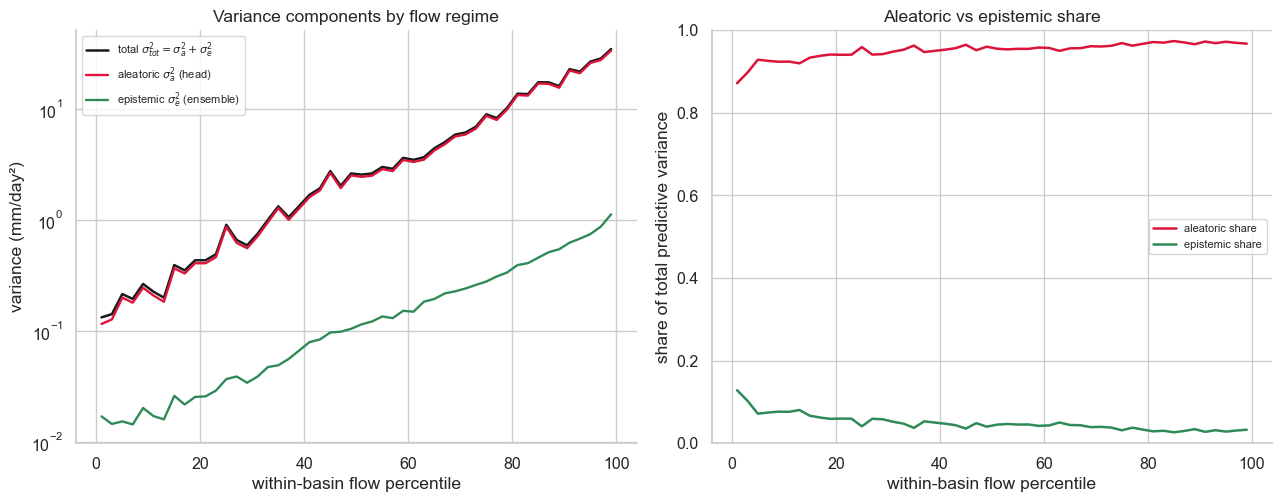

epistemic share: low-flow 0.13 -> high-flow 0.03 (aleatoric dominates; ensemble contribution collapses at high flow — matches EXP5 18/19)


In [7]:
# Cell: variance decomposition by flow regime (EXP5 cell 18/19 style, trained head's σ_a²)
FB = 50
pctD = pd.DataFrame(np.where(valid, y, np.nan)).rank(pct=True).to_numpy()
tbD = ald & np.isfinite(pctD); bD = np.clip(np.nan_to_num(pctD)*FB, 0, FB-1).astype(int)
ctrD, A, E, Vt = [], [], [], []
for k in range(FB):
    s = tbD & (bD==k)
    if s.sum()==0: continue
    A.append(np.mean(sigma_a2[s])); E.append(np.mean(sigma_e2[s])); Vt.append(np.mean(var_total[s])); ctrD.append((k+0.5)/FB*100)
A, E, Vt, ctrD = map(np.array, (A, E, Vt, ctrD))
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
ax[0].plot(ctrD, Vt, color="k", lw=1.8, label=r"total $\sigma^2_{tot}=\sigma_a^2+\sigma_e^2$")
ax[0].plot(ctrD, A, color="crimson", lw=1.7, label=r"aleatoric $\sigma_a^2$ (head)")
ax[0].plot(ctrD, E, color="seagreen", lw=1.7, label=r"epistemic $\sigma_e^2$ (ensemble)")
ax[0].set(xlabel="within-basin flow percentile", ylabel="variance (mm/day²)", yscale="log",
          title="Variance components by flow regime"); ax[0].legend(fontsize=8)
ax[1].plot(ctrD, A/Vt, color="crimson", lw=1.8, label="aleatoric share")
ax[1].plot(ctrD, E/Vt, color="seagreen", lw=1.8, label="epistemic share")
ax[1].set(xlabel="within-basin flow percentile", ylabel="share of total predictive variance",
          ylim=(0, 1), title="Aleatoric vs epistemic share"); ax[1].legend(fontsize=8)
sns.despine(fig); plt.tight_layout(); plt.show()
print(f"epistemic share: low-flow {E[0]/Vt[0]:.2f} -> high-flow {E[-1]/Vt[-1]:.2f} "
      "(aleatoric dominates; ensemble contribution collapses at high flow — matches EXP5 18/19)")

### What shape did the head learn? — the asymmetry τ
The ALD's τ is the skew knob: **τ<0.5 ⇒ fat upper tail** (more mass above μ̂), τ=0.5 is a symmetric Laplace. Left: learned τ across test cells (how far, and which way, the head skews). Right: τ by flow regime — does the head skew *more* where the big under-predictions live?

/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_30479/3959142575.py:18: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  sns.despine(fig); plt.tight_layout(); plt.show()
/Users/justingallant/.pyenv/versions/ealstm-postprocessing-py-3-10-11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


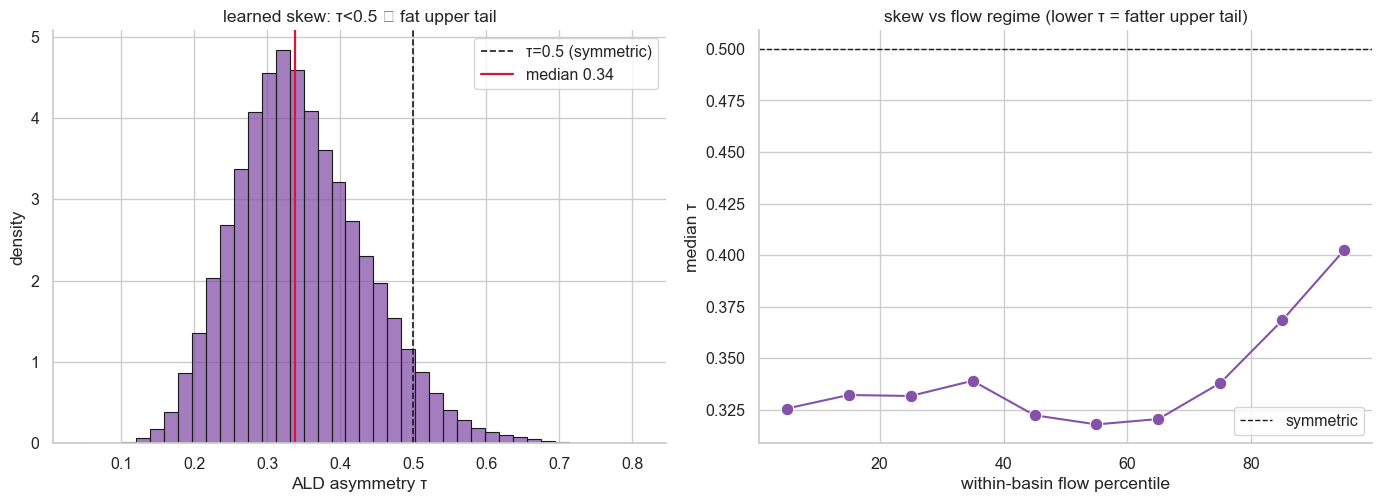

median τ (test): 0.338 | share τ<0.5 (upper-skew): 94.5%


In [8]:
# Cell: what shape did the ALD learn? — asymmetry tau (tau<0.5 = fat upper tail)
tau_c = tau_ald[ald]
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
sns.histplot(tau_c, bins=40, stat="density", color="#8452a8", edgecolor="k", ax=ax[0])
ax[0].axvline(0.5, ls="--", c="k", lw=1.2, label="τ=0.5 (symmetric)")
ax[0].axvline(np.median(tau_c), c="crimson", lw=1.6, label=f"median {np.median(tau_c):.2f}")
ax[0].set(xlabel="ALD asymmetry τ", ylabel="density", title="learned skew: τ<0.5 ⇒ fat upper tail")
ax[0].legend()
med, cc = [], []
for k in range(10):
    sel = tb & (bi == k)
    if sel.sum() == 0: continue
    med.append(np.median(tau_ald[sel])); cc.append((k + 0.5) * 10)
sns.lineplot(x=cc, y=med, marker="o", markersize=9, color="#8452a8", ax=ax[1])
ax[1].axhline(0.5, ls="--", c="k", lw=1, label="symmetric")
ax[1].set(xlabel="within-basin flow percentile", ylabel="median τ",
          title="skew vs flow regime (lower τ = fatter upper tail)"); ax[1].legend()
sns.despine(fig); plt.tight_layout(); plt.show()
print(f"median τ (test): {np.median(tau_c):.3f} | share τ<0.5 (upper-skew): {100*np.mean(tau_c<0.5):.1f}%")

## 6. Formal calibration — do the intervals actually cover?
Now, and only now, the ML metric. **PIT** = the observation's position in its own predictive CDF; if honest, PIT is **uniform on [0,1]**. A central hump = intervals too wide; a spike at **1.0** = observations in the far upper tail = under-covering the high side. Coverage is then read by flow regime — the tail is where it fails.

/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_30479/13045149.py:18: RuntimeWarning: overflow encountered in exp
  return np.where(zz < m, tau*np.exp((1-tau)/b*(zz-m)),


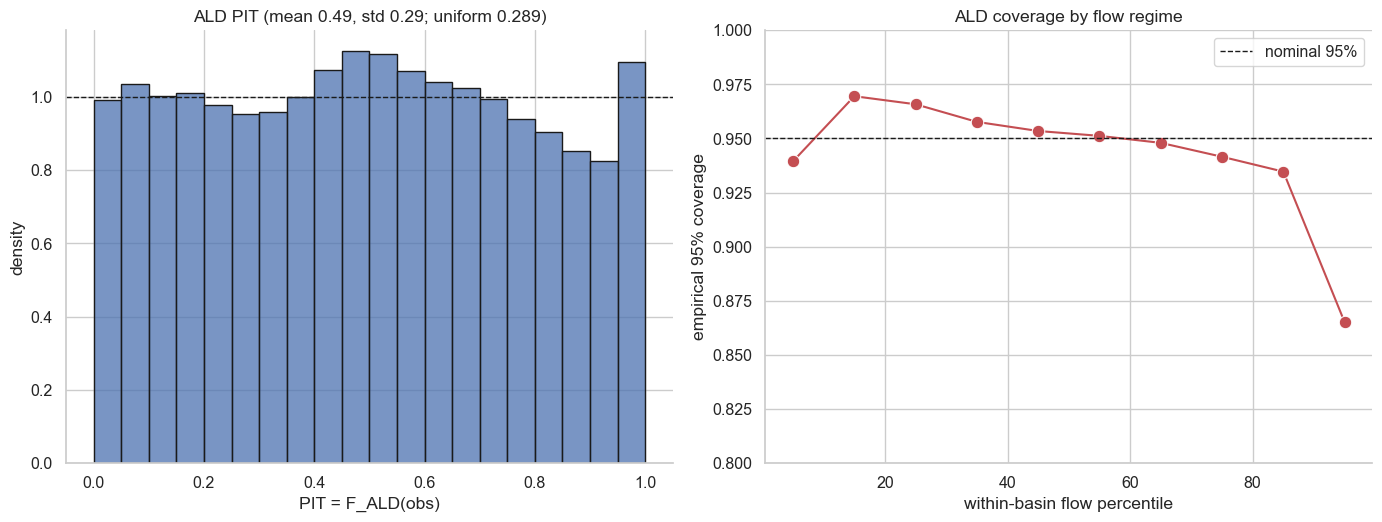

top-decile 95% ALD coverage: 0.865 (nominal 0.95)
heat_dome_2021: 95% ALD coverage 0.964  (n=16409)
ar_flood_2021: 95% ALD coverage 0.924  (n=10656)


In [9]:
# Cell 7: ALD-CDF PIT + coverage by flow regime (skew-aware; helpers/params from the load cell)
z = (y - mu) / q_std[None, :]                         # standardized residual (z-units; matches b, tau)
F = ald_cdf(z, m_z, b_ald, tau_ald)                   # PIT on the full grid (aleatoric ALD; sigma_e negligible)
pit = F[ald]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
sns.histplot(pit, bins=20, stat="density", edgecolor="k", color="#4c72b0", ax=axes[0])
axes[0].axhline(1, ls="--", c="k", lw=1)
axes[0].set(xlabel="PIT = F_ALD(obs)", ylabel="density",
            title=f"ALD PIT (mean {pit.mean():.2f}, std {pit.std():.2f}; uniform 0.289)")

# central-95% ALD coverage = fraction with PIT in [0.025, 0.975], by flow regime (asymmetric interval)
lo, hi = 0.025, 0.975
covered = (F >= lo) & (F <= hi)
cov, cc = [], []
for k in range(10):
    sel = tb & (bi == k)
    if sel.sum() == 0: continue
    cov.append(covered[sel].mean()); cc.append((k + 0.5) * 10)
sns.lineplot(x=cc, y=cov, marker="o", markersize=9, color="#c44e52", ax=axes[1])
axes[1].axhline(0.95, ls="--", c="k", lw=1, label="nominal 95%")
axes[1].set(xlabel="within-basin flow percentile", ylabel="empirical 95% coverage",
            title="ALD coverage by flow regime", ylim=(0.8, 1.0)); axes[1].legend()
sns.despine(fig); plt.tight_layout(); plt.show()
print(f"top-decile 95% ALD coverage: {cov[-1]:.3f} (nominal 0.95)")
for name, (a, b) in EVENTS.items():
    m = ((dates >= a) & (dates <= b))[:, None] & valid
    print(f"{name}: 95% ALD coverage {covered[m].mean():.3f}  (n={int(m.sum())})")

### Tail exceedance by flow regime — ensemble σ_e vs ALD total
One-sided upper exceedance = fraction of obs above the **97.5% upper bound** (nominal 2.5%), by within-basin flow percentile. Two channels: the **ensemble σ_e alone** (bound μ̂ + 1.96 σ_e — head-independent, the epistemic proxy) vs the **ALD total** (bound = the skew-aware 97.5% quantile `ald_hi`). The ensemble line climbs steeply at high flow — confidently wrong, D-blind — while the ALD total's fat upper tail pulls exceedance back toward nominal. The residual gap at the very top decile is the epistemic piece the head cannot supply.

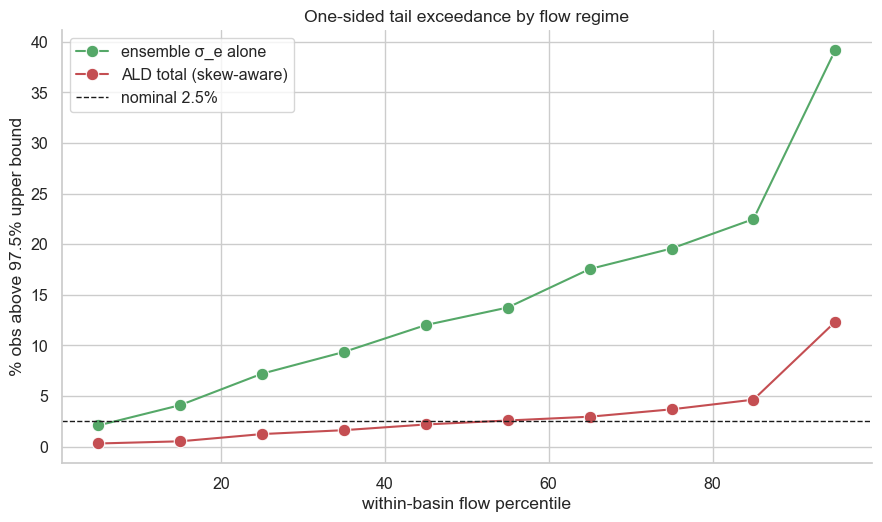

top-decile exceedance:  ensemble σ_e 39.2%   ALD total 12.3%   (nominal 2.5%)


In [10]:
# Cell: one-sided tail exceedance by flow regime — ensemble sigma_e vs ALD total (uses ald_hi)
Z = 1.96
up_e = y > (mu + Z*sig_e)         # ensemble-only upper bound (symmetric; head-independent)
up_t = y > ald_hi                 # ALD total upper bound = skew-aware 97.5% quantile
ce, ct, cc = [], [], []
for k in range(10):
    sel = tb & (bi == k)
    if sel.sum() == 0: continue
    ce.append(100*up_e[sel].mean()); ct.append(100*up_t[sel].mean()); cc.append((k+0.5)*10)
fig, ax = plt.subplots(figsize=(9, 5.4))
sns.lineplot(x=cc, y=ce, marker="o", markersize=9, color="#55a868", ax=ax, label="ensemble σ_e alone")
sns.lineplot(x=cc, y=ct, marker="o", markersize=9, color="#c44e52", ax=ax, label="ALD total (skew-aware)")
ax.axhline(2.5, ls="--", c="k", lw=1, label="nominal 2.5%")
ax.set(xlabel="within-basin flow percentile", ylabel="% obs above 97.5% upper bound",
       title="One-sided tail exceedance by flow regime")
ax.legend(); sns.despine(fig); plt.tight_layout(); plt.show()
print(f"top-decile exceedance:  ensemble σ_e {ce[-1]:.1f}%   ALD total {ct[-1]:.1f}%   (nominal 2.5%)")

### Normal QQ — where the Gaussian fails (low vs high flow)

Standardized residual z = (y − μ̂)/σ_total vs the standard normal; on the 45° line = calibrated Gaussian. 

Two views:
**(1) zoomed, symmetric scale** 
shows the *bulk shape* — low flow shallower than the line (over-dispersed, intervals too wide), high flow compressed then peeling up. 

**(2) full scale**
shows *how heavy the upper tail actually gets* — the high-flow tail runs to z ≈ tens (obs many predictive-SDs above μ̂) while low flow stays contained. The departure is one-sided and regime-dependent → an asymmetric, heavy-tailed head (CMAL), not merely a wider symmetric σ.

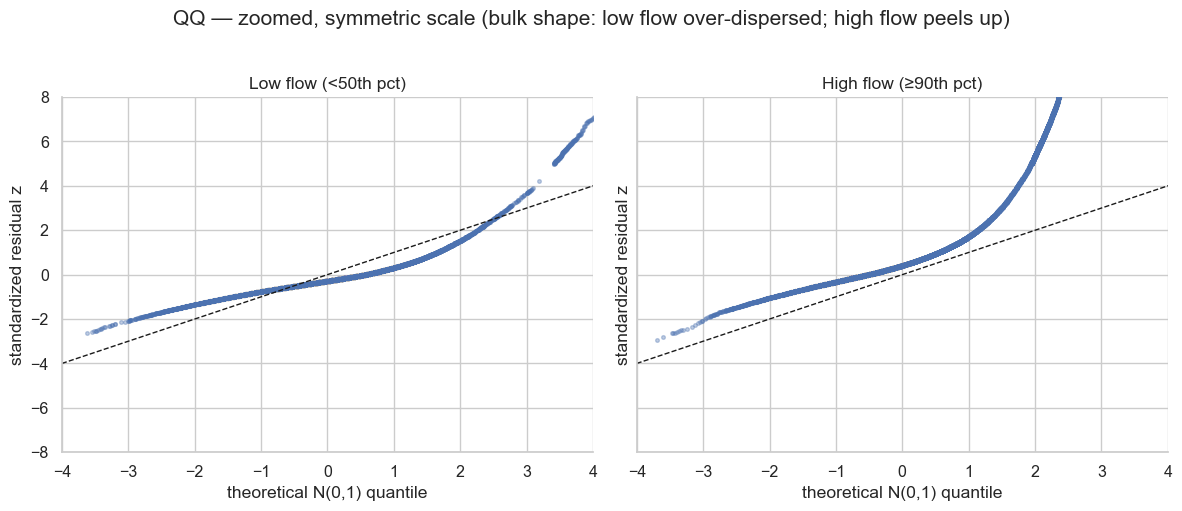

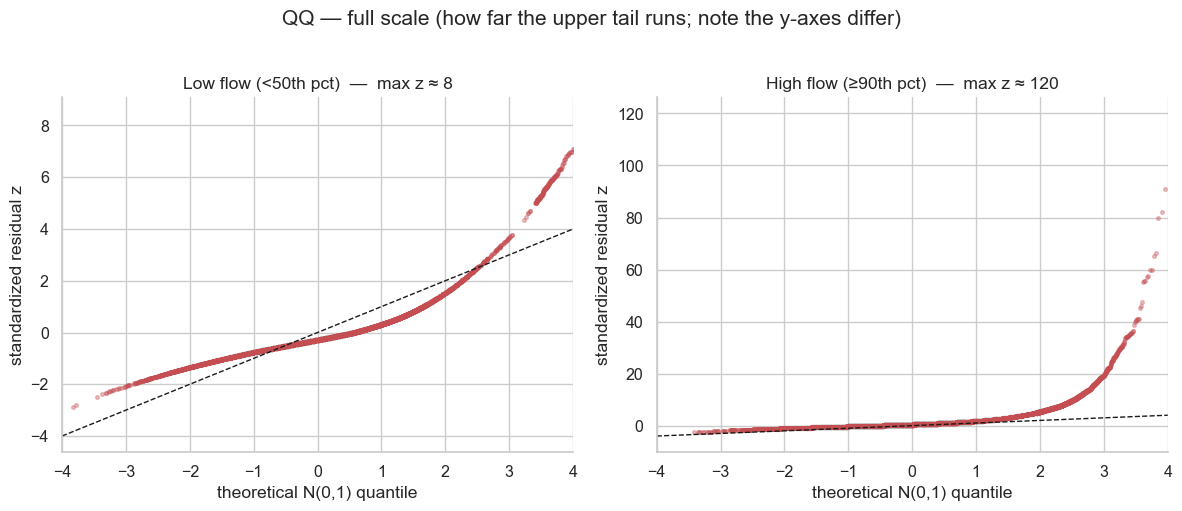

Zoomed: low flow shallower than the line (over-dispersed); high flow compressed then peeling up.
Full scale: high-flow upper tail runs to z ~ tens (obs many predictive-SDs above μ̂); low flow stays contained -> asymmetric heavy tail (CMAL).


In [11]:
# Cell: normal QQ of standardized residuals z=(y-μ̂)/σ_total, low vs high flow.
# alpha'd points; bulk subsampled for the density look + full tail kept so the extreme still shows.
# Two views: (1) zoomed + symmetric -> bulk shape;  (2) full scale -> how heavy the tail gets.
zg = (y - mu) / sig_tot
pctQ = pd.DataFrame(np.where(valid, y, np.nan)).rank(pct=True).to_numpy()
PANELS = [(pctQ < 0.5, "Low flow (<50th pct)"), (pctQ >= 0.9, "High flow (≥90th pct)")]
rng = np.random.default_rng(0)
def qq_pts(m, nsub=12000, keep_above=5.0):
    z = np.sort(zg[m & ald & np.isfinite(pctQ)]); n = z.size
    th = norm.ppf((np.arange(1, n+1) - 0.5)/n)
    keep = np.zeros(n, bool); keep[rng.choice(n, min(nsub, n), replace=False)] = True
    keep |= (z > keep_above)                                   # always draw the full upper tail
    return th[keep], z[keep], float(z[-1])

# (1) zoomed, symmetric scale — the bulk shape
YS = 8
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for a, (m, t) in zip(ax, PANELS):
    th, z, _ = qq_pts(m)
    a.plot([-YS, YS], [-YS, YS], ls="--", c="k", lw=1)
    a.scatter(th, z, s=7, alpha=.35, color="#4c72b0")
    a.set(title=t, xlabel="theoretical N(0,1) quantile", ylabel="standardized residual z",
          xlim=(-4, 4), ylim=(-YS, YS))
fig.suptitle("QQ — zoomed, symmetric scale (bulk shape: low flow over-dispersed; high flow peels up)", y=1.02)
sns.despine(fig); plt.tight_layout(); plt.show()

# (2) full scale — how heavy the upper tail really gets (independent y so each is legible)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, (m, t) in zip(ax, PANELS):
    th, z, zmax = qq_pts(m)
    a.plot([-4, 4], [-4, 4], ls="--", c="k", lw=1)
    a.scatter(th, z, s=7, alpha=.35, color="#c44e52")
    a.set(title=f"{t}  —  max z ≈ {zmax:.0f}", xlabel="theoretical N(0,1) quantile",
          ylabel="standardized residual z", xlim=(-4, 4))
fig.suptitle("QQ — full scale (how far the upper tail runs; note the y-axes differ)", y=1.02)
sns.despine(fig); plt.tight_layout(); plt.show()
print("Zoomed: low flow shallower than the line (over-dispersed); high flow compressed then peeling up.")
print("Full scale: high-flow upper tail runs to z ~ tens (obs many predictive-SDs above μ̂); low flow stays contained -> asymmetric heavy tail (CMAL).")

### Tail shape at the event — Gaussian vs ALD predictive density on Q
The two heads' **aleatoric predictive density** over streamflow (σ_e negligible), at the 2021 event cells. The Gaussian is symmetric about μ̂ and dies to zero well left of the observation; the ALD keeps a similar centre but stretches a **fat upper tail** toward the peak. `P(Y ≥ obs)` under each head (in the title) is the honest, distribution-agnostic read — the ALD assigns the event orders of magnitude more probability, which is what a z-score (a Gaussian-unit metric) hides.

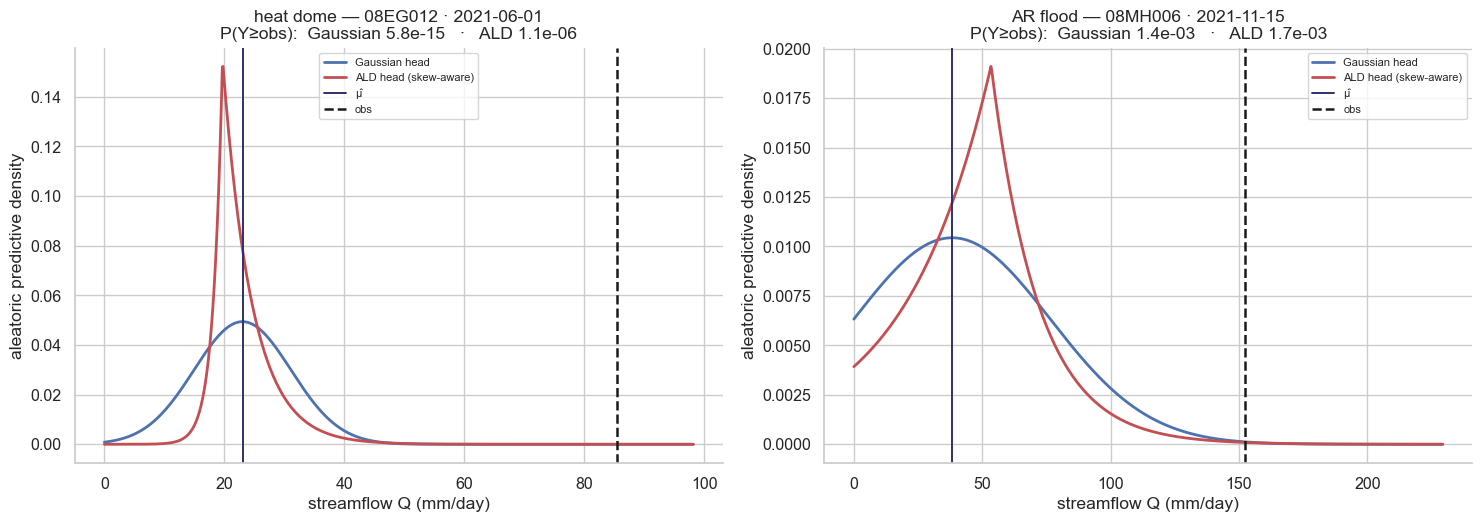

In [12]:
# Cell: tail shape at the event — Gaussian vs ALD predictive density on Q (aleatoric)
from scipy.stats import norm as _norm
gpred = np.load(RESULTS/"variance"/"predictive.npz")          # Gaussian run (variance/)
sigA_g = np.sqrt(gpred["sigma_a2"])                           # Gaussian aleatoric std (mm/day)

def ald_pdf_phys(q, loc, s, tau):
    u = (q - loc) / s
    rho = u * (tau - (u < 0).astype(float))                   # asymmetric check function
    return (tau * (1 - tau) / s) * np.exp(-rho)

EVCELLS = [("heat dome", "08EG012", "2021-06-01"), ("AR flood", "08MH006", "2021-11-15")]
fig, ax = plt.subplots(1, 2, figsize=(15, 5.4))
for a, (ttl, stn, day) in zip(ax, EVCELLS):
    j = int(np.where(stations == stn)[0][0]); i = int(np.where(dates == pd.Timestamp(day))[0][0])
    mu_i, obs_i, qs = mu[i, j], y[i, j], q_std[j]
    loc = mu_i + qs * m_z[i, j]; s = qs * b_ald[i, j]; tau = tau_ald[i, j]   # ALD physical, mean-recentered
    sg = sigA_g[i, j]
    qgrid = np.linspace(0, max(obs_i * 1.15, mu_i + 5 * sg, loc + 7 * s), 800)
    a.plot(qgrid, _norm.pdf(qgrid, mu_i, sg), color="#4c72b0", lw=2, label="Gaussian head")
    a.plot(qgrid, ald_pdf_phys(qgrid, loc, s, tau), color="#c44e52", lw=2, label="ALD head (skew-aware)")
    a.axvline(mu_i, color="#2f2f6f", lw=1.4, label="μ̂")
    a.axvline(obs_i, color="k", ls="--", lw=1.8, label="obs")
    pit_g = float(_norm.cdf((obs_i - mu_i) / sg))
    pit_a = float(ald_cdf((obs_i - mu_i) / qs, m_z[i, j], b_ald[i, j], tau))
    a.set(title=f"{ttl} — {stn} · {day}\nP(Y≥obs):  Gaussian {1-pit_g:.1e}   ·   ALD {1-pit_a:.1e}",
          xlabel="streamflow Q (mm/day)", ylabel="aleatoric predictive density")
    a.legend(fontsize=8)
sns.despine(fig); plt.tight_layout(); plt.show()

**Takeaway.** Uncertainty is largest in glacier-fed/coastal basins and grows with flow (physical).

The head is *competent* (§4: σ_a resolves the error, Spearman ≈0.74 — not a too-weak head) and its magnitude is reasonable-to-generous.

The remaining question is **shape**: the residuals are right-skewed, which is exactly what the **ALD head** targets. The ALD PIT (§6) is the acceptance test for whether the skew-aware tail now covers the high-flow peak. The *epistemic* half — the ensemble being confidently wrong at the extreme (≈39% top-decile exceedance under σ_e alone) — is head-independent and lives in EXP6; the open fork from here is formal-epistemic (Bayesian) UQ.

## The one figure: did the skew-aware tail help?

The standardized residual **z = (obs − μ̂) / σ_total** in one picture, now under the **ALD head**. In the bulk it stays roughly unit-scale; the 2021 heat-dome peak at **08EG012** (obs 85 vs μ̂ 23 mm/day — μ̂ is frozen, so the *error* is unchanged from EXP6) is annotated with its actual z. Compare directly to EXP6's Gaussian baseline of **z ≈ 7.5**: if the ALD's fatter upper tail widened σ_total there, the spike moves in; if it can't — because the head never saw such an event in-distribution — the event stays far out, isolating the failure as **epistemic**, not likelihood-shape. The inset shows the tri-part signature (needed |obs−μ̂| vs supplied σ_a, σ_e). The **exact** calibration test is the ALD PIT (§6); this figure is the intuitive companion.

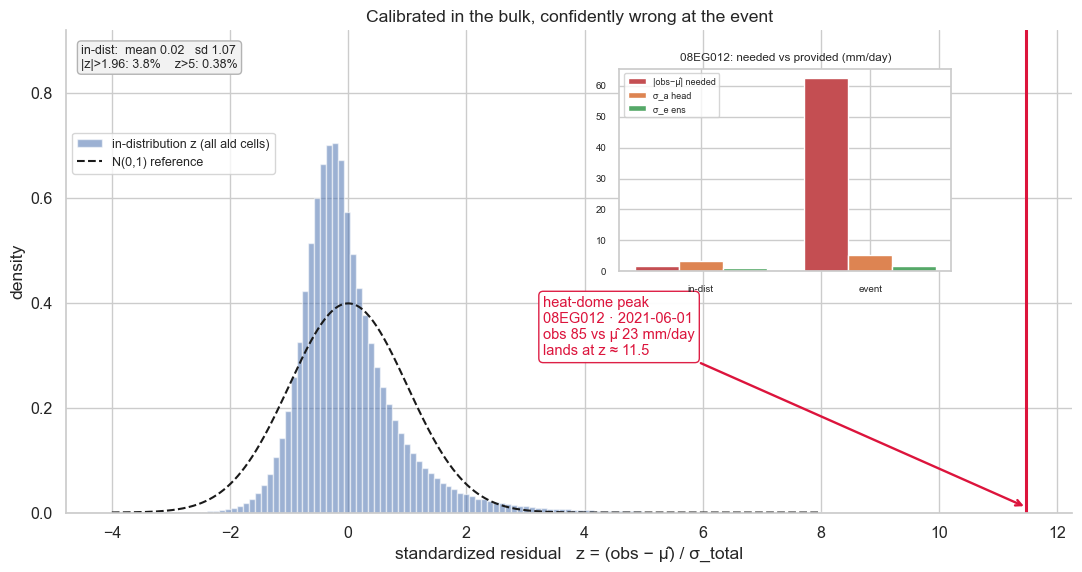

z_event=11.5 | needed 62 mm vs supplied σ_a 5+σ_e 2 mm


In [13]:
# Cell: THE figure — z is unit-scale in-distribution, a far-tail spike at the event
z = (y - mu) / sig_tot
zt = z[ald]; zt = zt[np.isfinite(zt)]
STN, DAY = "08EG012", pd.Timestamp("2021-06-01")            # heat-dome peak, confidently-wrong cell
j = int(np.where(stations == STN)[0][0]); i = int(np.where(dates == DAY)[0][0])
z_ev = z[i, j]; m = ald[:, j]

fig, ax = plt.subplots(figsize=(11, 5.9))
ax.hist(zt, bins=np.linspace(-4, 8, 120), density=True, color="#4c72b0", alpha=.55,
        label="in-distribution z (all ald cells)")
xx = np.linspace(-4, 8, 400); ax.plot(xx, norm.pdf(xx), "k--", lw=1.5, label="N(0,1) reference")
ax.axvline(z_ev, color="crimson", lw=2.2)
ax.annotate(f"heat-dome peak\n{STN} · {DAY.date()}\nobs {y[i,j]:.0f} vs μ̂ {mu[i,j]:.0f} mm/day\nlands at z ≈ {z_ev:.1f}",
            xy=(z_ev, 0.010), xytext=(3.3, 0.30), fontsize=10.5, color="crimson", ha="left",
            arrowprops=dict(arrowstyle="->", color="crimson", lw=1.7),
            bbox=dict(boxstyle="round", fc="white", ec="crimson", alpha=.95))
ax.text(0.015, 0.97, f"in-dist:  mean {zt.mean():.2f}   sd {zt.std():.2f}\n"
        f"|z|>1.96: {100*np.mean(np.abs(zt)>1.96):.1f}%    z>5: {100*np.mean(zt>5):.2f}%",
        transform=ax.transAxes, va="top", fontsize=9, bbox=dict(boxstyle="round", fc="0.95", ec="0.7"))
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 0.80), fontsize=9)
ax.set(xlabel="standardized residual   z = (obs − μ̂) / σ_total", ylabel="density",
       title="Calibrated in the bulk, confidently wrong at the event", ylim=(0, 0.92))
# inset: tri-part signature — error to cover vs widths supplied, event vs in-distribution
need_ev = abs(y[i, j] - mu[i, j])
iax = ax.inset_axes([0.55, 0.50, 0.33, 0.42]); xb = np.arange(2); w = .26
iax.bar(xb-w, [np.median(np.abs(y[m, j]-mu[m, j])), need_ev], w, color="#c44e52", label="|obs−μ̂| needed")
iax.bar(xb,   [np.median(sig_a[m, j]), sig_a[i, j]], w, color="#dd8452", label="σ_a head")
iax.bar(xb+w, [np.median(sig_e[m, j]), sig_e[i, j]], w, color="#55a868", label="σ_e ens")
iax.set_xticks(xb); iax.set_xticklabels(["in-dist", "event"], fontsize=8)
iax.set_title(f"{STN}: needed vs provided (mm/day)", fontsize=8.5)
iax.tick_params(labelsize=7); iax.legend(fontsize=6.5, loc="upper left")
sns.despine(fig); plt.tight_layout(); plt.show()
print(f"z_event={z_ev:.1f} | needed {need_ev:.0f} mm vs supplied σ_a {sig_a[i,j]:.0f}+σ_e {sig_e[i,j]:.0f} mm")